# 03 Customer Segmentation

Group invoices into behavioural segments so the business can target campaigns instead of blasting every customer with the same offer. The classical tool here is RFM (Recency, Frequency, Monetary) followed by KMeans.

This dataset does not carry a repeat customer identifier, so we cannot compute true Frequency the textbook way. The workaround:

1. Treat every invoice as one customer touchpoint.
2. **Recency** = days from the invoice date to one day past the dataset max.
3. **Frequency** is replaced with **Quantity** (items in the basket). It still varies meaningfully and acts as a loyalty proxy.
4. **Monetary** = invoice total.

`Frequency` and `Monetary` are right skewed, so they are passed through `log1p` before scaling. Then `StandardScaler` normalises all three features to zero mean and unit variance, which KMeans needs because it relies on Euclidean distance.

K is selected by silhouette score across `k = 3 .. 6`. The winner is the K with the highest silhouette, not the lowest within cluster sum of squares, because silhouette is more interpretable and penalises clusters that bleed into each other.

Output: `kmeans.joblib` (the model), `rfm_scaler.joblib` (the StandardScaler), `segments.parquet` (per invoice assignment), `segment_profiles.parquet` (per segment averages used by the dashboard).

In [1]:
import os, warnings
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
os.environ.setdefault('TQDM_DISABLE', '1')
warnings.filterwarnings('ignore')
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.viz import set_style, fmt_money

set_style()
RNG = np.random.default_rng(config.RANDOM_SEED)


In [2]:
from src.data_loader import load_processed
from src.features import rfm_table
from src.modelling import fit_kmeans
import joblib

df = load_processed()
rfm = rfm_table(df)
print('rfm shape:', rfm.shape)
rfm.head()


rfm shape: (957, 8)


,Invoice ID,Recency,Frequency,Monetary,AvgRating,Branch,CustomerType,DominantProduct
0,101-17-6199,18,7.0,336.5565,7.0,A,Normal,Food and beverages
1,102-06-2002,11,5.0,132.5625,6.1,C,Member,Sports and travel
2,102-77-2261,26,7.0,480.0285,4.2,C,Member,Health and beauty
3,105-10-6182,32,2.0,45.1080,6.6,A,Normal,Fashion accessories
4,105-31-1824,58,7.0,510.9720,8.5,A,Member,Sports and travel


## Fit KMeans across k


In [3]:
result = fit_kmeans(rfm, k_range=range(3, 7))
print('best k:', result.k, 'silhouette:', round(result.silhouette, 3))
rfm['Segment'] = result.labels


best k: 3 silhouette: 0.356


## Profile each segment


Each segment is profiled on size, average Recency, average Quantity, average Monetary, and average Rating. These are the columns the Streamlit Customer Segments page surfaces, so the labels here drive what the business user sees in the dashboard.

In [4]:
profile = rfm.groupby('Segment').agg(
    Customers=('Invoice ID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    AvgRating=('AvgRating', 'mean'),
).round(2)
profile['Share'] = profile['Customers'] / profile['Customers'].sum()
profile


,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgRating,Share
Segment,,,,,,
0,348,20.53,6.39,375.09,6.91,0.363636
1,237,47.05,1.94,84.45,7.05,0.247649
2,372,65.66,7.08,436.10,7.05,0.388715


## Visualise the segments


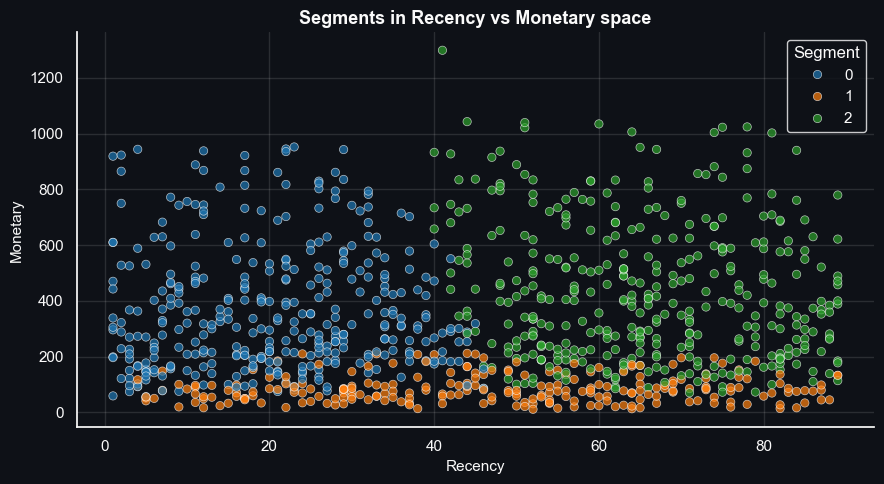

In [5]:
ax = sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='tab10', alpha=0.7)
ax.set_title('Segments in Recency vs Monetary space')
plt.tight_layout(); plt.show()


## Save model artifacts


In [6]:
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(result.model, config.KMEANS_MODEL)
joblib.dump(result.scaler, config.SCALER_MODEL)
rfm.to_parquet(config.SEGMENTS_PARQUET, index=False)
profile.to_parquet(config.SEGMENT_PROFILES_PARQUET)
print('saved:', config.KMEANS_MODEL, config.SEGMENTS_PARQUET, config.SEGMENT_PROFILES_PARQUET)


saved: D:\ZE5 PORTOFOLIO DS\Retail-Analytics-And-Forecasting-Platform\models\kmeans.joblib D:\ZE5 PORTOFOLIO DS\Retail-Analytics-And-Forecasting-Platform\data\processed\segments.parquet D:\ZE5 PORTOFOLIO DS\Retail-Analytics-And-Forecasting-Platform\data\processed\segment_profiles.parquet


## Action recommendations

1. The highest monetary, lowest recency segment is the loyalty target; route them into a paid membership tier.
2. The lowest monetary, highest recency segment is the churn risk; reactivate with targeted promotions on Food and beverages where the rating is highest.
3. Mid tiers are the volume cohort and respond best to bundling and weekday promotions.
